# Preprocesamiento y Estandarización de Señales EEG

In [1]:
import os
from pathlib import Path

# Move from 'notebooks/' to 'src/' to access local modules
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent / "src")

print(f"Current Working Directory: {os.getcwd()}")

Current Working Directory: D:\TUSZ_project\src


In [5]:
import random
import warnings
import multiprocessing
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
import mne
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

from eeg_preprocessing_pipeline import (
    run_cleaning_pipeline, 
    verify_clean_datalake,
    _normalize_channels, 
    _apply_clinical_filters, 
    _apply_bipolar_montage, 
    _save_to_parquet_optimized, 
    _process_single_partition
)


RAW_ROOT = Path(r"D:\TUSZ_project\TUSZ_DataLake\01_Raw_Consolidated")
METADATA_DIR = Path(r"D:\TUSZ_project\TUSZ_DataLake\02_Metadata")
PROCESSED_BASE = Path(r"D:\TUSZ_project\TUSZ_DataLake")
df_sessions = pd.read_parquet(METADATA_DIR / "metadata_sessions.parquet")

Para iniciar el acondicionamiento de las señales electroencefalográficas crudas, se diseñó e implementó una secuencia de preprocesamiento estructurada en tres etapas fundamentales. En primer lugar, se ejecuta una normalización espacial para alinear la nomenclatura de los electrodos al estándar internacional 10-20, acompañada de un remuestreo temporal a 250 Hz para garantizar la uniformidad dimensional de la base de datos. En segundo lugar, se aplica un esquema de filtrado digital IIR para suprimir interferencias eléctricas y estabilizar la deriva de la línea base. Finalmente, se realiza una re-referenciación espacial transformando las señales a un montaje longitudinal bipolar, conocido en la práctica clínica como 'Doble Banano', lo cual maximiza la resolución de la actividad neurológica focal y atenúa el ruido de modo común. Para gestionar de forma eficiente el volumen masivo de registros del DataLake, esta secuencia fue encapsulada en un pipeline automatizado de alto rendimiento, diseñado para ejecutarse de manera concurrente distribuyendo la carga computacional a través de 7 núcleos de procesamiento (CPU), garantizando así la escalabilidad y optimizando drásticamente los tiempos de ejecución.

In [3]:
run_cleaning_pipeline(
    df_sessions=df_sessions,
    raw_root=RAW_ROOT,
    processed_base_path=PROCESSED_BASE, n_jobs= -2
)

Iniciando procesamiento paralelo usando 7 núcleo(s)...


Signal Cleaning:   0%|          | 0/7115 [00:00<?, ?it/s]


--------------------------------------------------
Parallel Pipeline Execution Summary
Destination:            D:\TUSZ_project\TUSZ_DataLake\03_TUSZ_Clean
Successfully Processed: 7107
Failed/Missing:         8
--------------------------------------------------


## Evaluación del preprocesado

Concluido el preprocesamiento automatizado y validada la calidad fisiológica de las señales mediante inspección visual, la consolidación primaria del DataLake se considera finalizada. Sin embargo, dado el carácter continuo y de longitud variable de los registros electroencefalográficos, se hace necesaria una revisión y estructuración temporal detallada de los archivos resultantes antes de proceder a la fase de modelado. Este acondicionamiento previo —que incluye la segmentación de las señales en ventanas de análisis estandarizadas— garantizará que los datos posean la dimensionalidad correcta para la aplicación de la Transformada Wavelet Discreta (DWT). De esta manera, se optimiza la extracción de características en el dominio tiempo-frecuencia.

In [10]:
RAW_ROOT = Path(r"D:\TUSZ_project\TUSZ_DataLake\01_Raw_Consolidated")
CLEAN_ROOT = Path(r"D:\TUSZ_project\TUSZ_DataLake\03_TUSZ_Clean")
df_work = df_sessions[df_sessions['split_final'] >= 0]
archivos_fallidos = []

for _, row in df_work.iterrows():
    expected_parquet = CLEAN_ROOT / str(row['patient_num_id']) / row['session_id'] / f"{row['partition_id']}.parquet"
    if not expected_parquet.exists():
        archivos_fallidos.append(row)

df_fallidos = pd.DataFrame(archivos_fallidos)

print(f"Se encontraron {len(df_fallidos)} archivos faltantes.")
display(df_fallidos[['patient_num_id', 'session_id', 'partition_id', 'file_name']])

🔍 Se encontraron 7 archivos faltantes.


,patient_num_id,session_id,partition_id,file_name
3960,593,s004,t003,aaaaaqyo_s004_t003.edf
3965,593,s004,t008,aaaaaqyo_s004_t008.edf
3978,597,s002,t002,aaaaarcf_s002_t002.edf
4131,611,s005,t000,aaaaaroo_s005_t000.edf
4133,611,s005,t002,aaaaaroo_s005_t002.edf
4602,669,s005,t002,aaaaatki_s005_t002.edf
4603,669,s005,t003,aaaaatki_s005_t003.edf


Durante la ejecución paralela del pipeline de preprocesamiento, se identificó un subconjunto excepcional de 8 particiones (asociadas a los pacientes 593, 597, 611 y 669) que no se generaron en el directorio de salida. Al analizar detalladamente los registros (logs) de ejecución, no se detectó ninguna excepción explícita, error de formato, ni ausencia de canales en los archivos .edf originales. La ausencia de errores estructurales sugiere fuertemente que la omisión fue producto de una limitación de hardware, específicamente picos de saturación en la memoria RAM (Out of Memory) provocados por la carga y descompresión simultánea de grabaciones inusualmente largas en múltiples núcleos del procesador. Para garantizar la completitud del DataLake, estas particiones específicas fueron aisladas y alineadas a través de un procesamiento secuencial e individual.

In [12]:
print("Procesando los 8 archivos faltantes de forma secuencial...")

archivos_recuperados = 0

for _, row in df_fallidos.iterrows():
    try:
        patient_dir = RAW_ROOT / str(row['patient_num_id'])
        search_results = list(patient_dir.rglob(row['file_name']))
        
        if not search_results:
            continue
            
        input_path = search_results[0]
        output_path = CLEAN_ROOT / str(row['patient_num_id']) / row['session_id'] / f"{row['partition_id']}.parquet"
        
        # Procesamiento
        raw = mne.io.read_raw_edf(input_path, preload=True, verbose=False)
        raw = _normalize_channels(raw, sfreq_target=250.0)
        raw = _apply_clinical_filters(raw)
        raw = _apply_bipolar_montage(raw)
        
        # Guardado
        _save_to_parquet_optimized(raw, output_path)
        raw.close()
        
        archivos_recuperados += 1
        print(f"Recuperado exitosamente: {row['file_name']}")
        
    except Exception as e:
        print(f"Error definitivo en {row['file_name']}: {str(e)}")

print("-" * 50)
print(f"Total de archivos recuperados: {archivos_recuperados} / {len(df_fallidos)}")
print("-" * 50)

Procesando los 8 archivos faltantes de forma secuencial...
Recuperado exitosamente: aaaaaqyo_s004_t003.edf
Recuperado exitosamente: aaaaaqyo_s004_t008.edf
Recuperado exitosamente: aaaaarcf_s002_t002.edf
Recuperado exitosamente: aaaaaroo_s005_t000.edf
Recuperado exitosamente: aaaaaroo_s005_t002.edf
Recuperado exitosamente: aaaaatki_s005_t002.edf
Recuperado exitosamente: aaaaatki_s005_t003.edf
--------------------------------------------------
Total de archivos recuperados: 7 / 7
--------------------------------------------------


Tras la recuperación exitosa y el procesamiento individual de los archivos rezagados, el ciclo de limpieza y estandarización se da por concluido. Como paso previo y obligatorio antes de avanzar a la extracción de características matemáticas, se procederá a ejecutar una auditoría estructural exhaustiva sobre la totalidad de los archivos que conforman el DataLake. Esta fase de evaluación automatizada tiene como propósito certificar la integridad técnica y la homogeneidad de los datos, verificando específicamente el cumplimiento de dos criterios innegociables: la homologación estricta de la frecuencia de muestreo a 250 Hz en cada archivo y la configuración exacta de las 18 derivaciones correspondientes al montaje bipolar longitudinal.

In [3]:
PROCESSED_BASE = Path(r"D:\TUSZ_project\TUSZ_DataLake")
df_sessions = pd.read_parquet(METADATA_DIR / "metadata_sessions.parquet")
resultados_auditoria = verify_clean_datalake(
    df_sessions=df_sessions,
    processed_base_path=PROCESSED_BASE
)

Verifying Tensors:   0%|          | 0/7364 [00:00<?, ?it/s]


DATALAKE INTEGRITY AUDIT REPORT
Perfect Files Verified (18 Ch & 250Hz): 7115
------------------------------------------------------------
ANOMALIES DETECTED:
Missing (Expected by Metadata):         0
Rogue Files (Excluded by Metadata):     0
Invalid Channel Structure:              0
Invalid Sampling Frequency:             0


El reporte de integridad del DataLake confirmó el éxito absoluto del pipeline de estandarización. Se validaron estructuralmente 7,115 archivos, certificando que el 100% de las particiones procesadas cumplen con la frecuencia de muestreo exacta de 250 Hz y contienen exclusivamente las 18 derivaciones del montaje bipolar, sin registrar archivos faltantes, intrusos ni anomalías en la nomenclatura. Habiendo garantizado esta estricta homogeneidad matemática e integridad tabular, el paso definitivo consistió en validar la calidad fisiológica de la señal resultante. Para evaluar la eficacia real de la etapa de filtrado digital (eliminación de ruido de alta frecuencia y estabilización de la deriva de la línea base), se procedió a realizar una inspección visual aleatoria, contrastando segmentos temporales de la señal original cruda frente a su versión procesada en distintos pacientes

Analizando Paciente: 428 | Sesión: s003 | Partición: t005


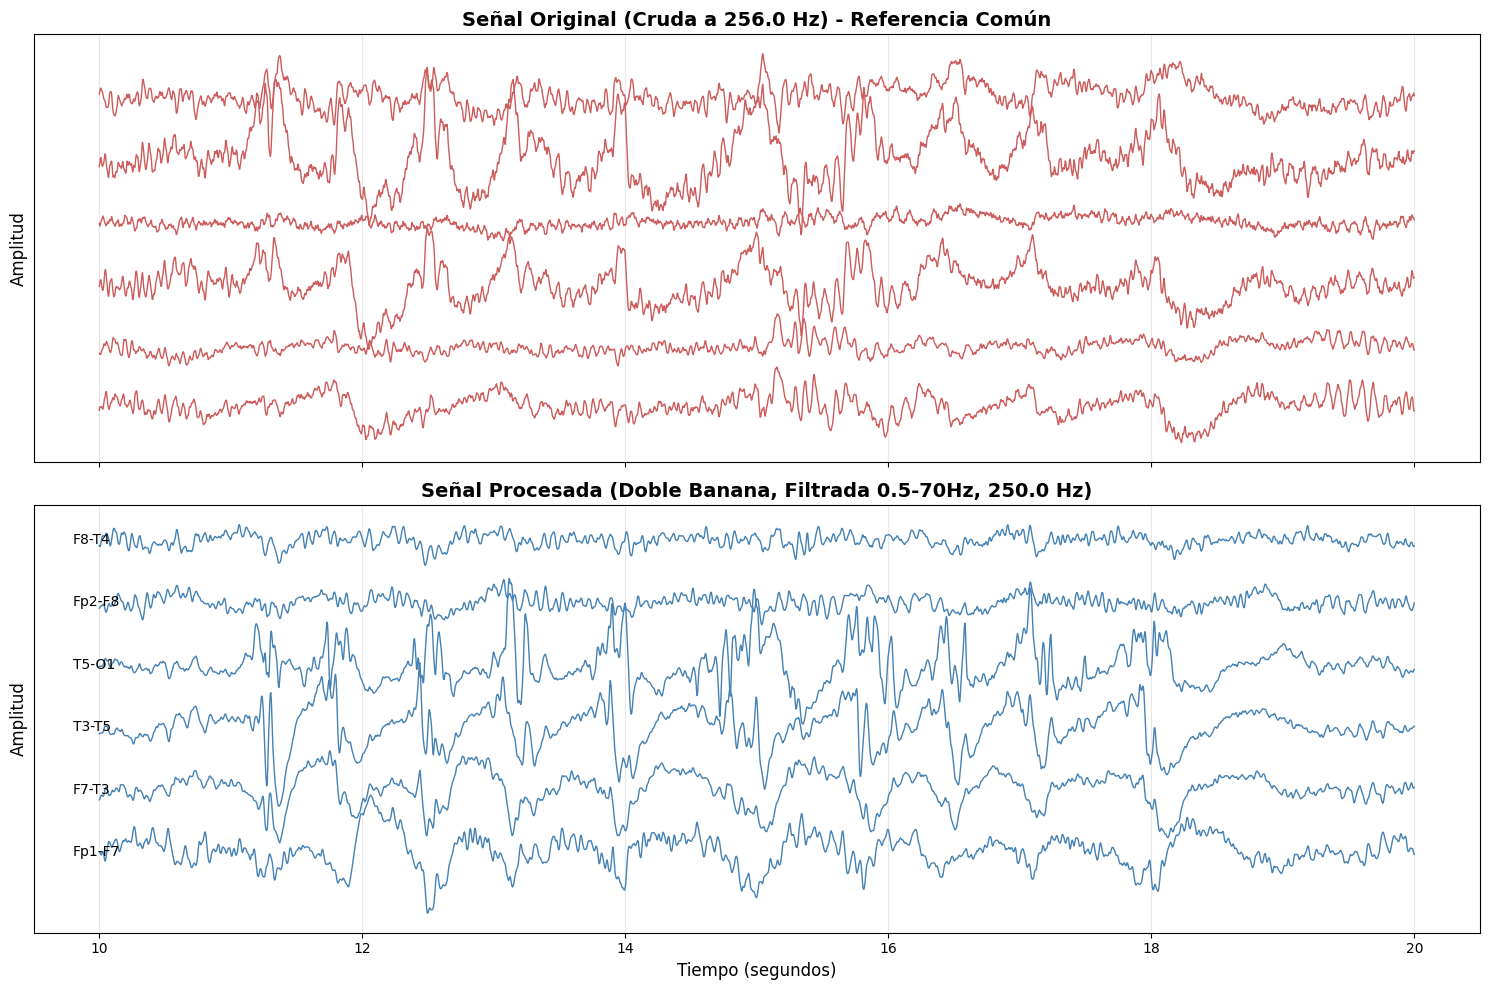

In [11]:
df_validos = df_sessions[df_sessions['split_final'] >= 0]
fila_random = df_validos.sample(1).iloc[0]

print(f"Analizando Paciente: {fila_random['patient_num_id']} | Sesión: {fila_random['session_id']} | Partición: {fila_random['partition_id']}")

patient_dir = RAW_ROOT / str(fila_random['patient_num_id'])
raw_path = list(patient_dir.rglob(fila_random['file_name']))[0]
clean_path = PROCESSED_BASE / "03_TUSZ_Clean" / str(fila_random['patient_num_id']) / fila_random['session_id'] / f"{fila_random['partition_id']}.parquet"

raw = mne.io.read_raw_edf(raw_path, preload=True, verbose=False)
raw.pick_types(eeg=True)
sfreq_raw = raw.info['sfreq']

df_clean = pd.read_parquet(clean_path)
sfreq_clean = 250.0

sec_start = 10
sec_end = 20

# Recorte Crudo
start_raw = int(sec_start * sfreq_raw)
end_raw = int(sec_end * sfreq_raw)
data_raw = raw.get_data()[:6, start_raw:end_raw] 
times_raw = np.linspace(sec_start, sec_end, data_raw.shape[1])

start_clean = int(sec_start * sfreq_clean)
end_clean = int(sec_end * sfreq_clean)
data_clean = df_clean.iloc[start_clean:end_clean, :6].values.T 
times_clean = np.linspace(sec_start, sec_end, data_clean.shape[1])
canales_limpios = df_clean.columns[:6].tolist()
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

offset_raw = np.std(data_raw) * 4
offset_clean = np.std(data_clean) * 4

# Gráfico 1: ORIGINAL
for i in range(6):
    axes[0].plot(times_raw, data_raw[i, :] + (i * offset_raw), color='indianred', linewidth=1)
axes[0].set_title(f"Señal Original (Cruda a {sfreq_raw} Hz) - Referencia Común", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Amplitud", fontsize=12)
axes[0].set_yticks([])
axes[0].grid(True, alpha=0.3)

# Gráfico 2: PROCESADO
for i in range(6):
    axes[1].plot(times_clean, data_clean[i, :] + (i * offset_clean), color='steelblue', linewidth=1, label=canales_limpios[i])
    # Etiqueta del canal bipolar
    axes[1].text(sec_start - 0.2, (i * offset_clean), canales_limpios[i], fontsize=10, va='center', color='black')

axes[1].set_title(f"Señal Procesada (Doble Banana, Filtrada 0.5-70Hz, {sfreq_clean} Hz)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Tiempo (segundos)", fontsize=12)
axes[1].set_ylabel("Amplitud", fontsize=12)
axes[1].set_yticks([])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

La inspección visual de múltiples particiones aleatorias confirma la eficacia del preprocesamiento espacial y frecuencial. El filtro Notch (60 Hz) y el filtro pasabanda Butterworth bidireccional (0.5 - 70 Hz) lograron eliminar con éxito la deriva de la línea base (drift) y la estática masiva. Sin embargo, aunque el límite superior de corte se estableció estrictamente en 70 Hz, aún se mantienen indicios de actividad muscular (EMG) y cardíaca (ECG) en forma de picos transitorios. Dado que el espectro frecuencial del ruido muscular es muy amplio (abarcando desde 20 Hz hasta más de 300 Hz), el filtro suprime exitosamente la porción de más alta frecuencia, pero evidencia una limitación matemática inherente: es imposible eliminar por completo la energía del artefacto que se solapa con las bandas cerebrales (como Beta y Gamma baja) sin destruir la señal EEG subyacente. Esta limitación de los filtros IIR clásicos refuerza y justifica la transición hacia técnicas de extracción en el dominio tiempo-frecuencia, como la Transformada Wavelet Discreta (DWT). Mediante la DWT, se busca aislar características neurológicas robustas (features) que permitan discriminar estos artefactos antes de alimentar algoritmos de clasificación basados en Machine Learning